# CS229 Kernel Methods — Practical Implementation on the Heart Disease Dataset

## 1. Introduction

**Concept we are implementing:** Kernel Methods (CS229, Chapter 5) — specifically the idea that
a **kernel function** $K(x,z) = \langle \phi(x), \phi(z)\rangle$ lets a linear-style algorithm operate
in a high-dimensional (or infinite-dimensional) **feature space** without ever computing
$\phi(x)$ explicitly.

**Problem we are solving:** Predict whether a patient has heart disease from clinical measurements.

**Dataset:** The Heart Failure Prediction dataset — 918 patient records with clinical attributes
(age, blood pressure, cholesterol, ECG results, etc.).

**Target variable:** `HeartDisease` — `1` = patient has heart disease, `0` = no heart disease.

**ML task:** **Binary classification.**

**Why kernels here?** Chapter 5 explains that the kernel trick was famously applied to **Support
Vector Machines (SVMs)**. We will train SVMs with different kernels — **linear**, **polynomial**,
and **RBF (Gaussian)** — on this dataset. This directly mirrors the chapter: the linear kernel
corresponds to $\phi(x) = x$ (no transformation), the polynomial kernel corresponds to a feature
map over monomials (Section 5.4), and the RBF kernel corresponds to an **infinite-dimensional**
feature map (also Section 5.4). We never construct $\phi(x)$ by hand — `sklearn`'s `SVC` computes
$K(x,z)$ directly, exactly the computational shortcut the chapter derives.


## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 3. Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_06_Kernels\Dataset.csv")
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Check the shape of the dataset:
# rows = number of patient records, columns = features + target
df.shape


(918, 12)

In [4]:
# Data types tell us which columns are numeric (already usable by a model)
# and which are categorical strings (need encoding before training).
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [5]:
# Summary statistics for the numeric columns.
# We'll use this to spot impossible values (e.g. a cholesterol of 0),
# which is a common issue in this dataset.
df.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
# Check for missing values encoded as NaN.
df.isnull().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## 4. Understand the Data

- **Target:** `HeartDisease` (0 / 1) — binary classification.
- **Numeric features:** `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`.
- **Categorical features:** `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- **No `NaN` values reported** — but that does not mean the data is clean. Let's check for
  values that are technically present but **medically impossible**.


In [7]:
# A resting cholesterol or blood pressure of 0 is not medically possible for a living patient.
# This dataset is known to encode missing measurements as 0 instead of NaN.
print("Rows with Cholesterol == 0:", (df["Cholesterol"] == 0).sum())
print("Rows with RestingBP == 0:  ", (df["RestingBP"] == 0).sum())


Rows with Cholesterol == 0: 172
Rows with RestingBP == 0:   1


In [8]:
# Target balance: a roughly balanced target means accuracy is a reasonable metric to report
# (we don't need to lean on precision/recall alone to compensate for severe imbalance).
df["HeartDisease"].value_counts(normalize=True)


HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

In [9]:
# Look at how many distinct categories each categorical column has,
# since this determines how many new columns one-hot encoding will create.
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

for col in categorical_cols:
    print(col, "->", df[col].unique())


Sex -> <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType -> <ArrowStringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG -> <ArrowStringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina -> <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope -> <ArrowStringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


## 5. Data Preprocessing

Two real issues need handling before this data is usable:

1. **`Cholesterol == 0`** (172 rows) and **`RestingBP == 0`** (1 row) are placeholders for
   missing measurements, not real zeros. We replace them with `NaN` and let the model pipeline
   impute them (using the **median**, computed only on the training fold — see below).
2. **Categorical columns** (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`)
   must be converted to numbers before they can enter $\langle x, z\rangle$ or any kernel
   computation — `SVC` only accepts numeric input. We use **one-hot encoding** since these
   categories have no natural order.
3. **Feature scaling.** Kernels such as the RBF kernel, $K(x,z)=\exp(-\lVert x-z\rVert^2 / 2\sigma^2)$,
   depend directly on the Euclidean distance $\lVert x - z\rVert$. If `Cholesterol` (values up to
   ~600) and `FastingBS` (values 0 or 1) are left unscaled, the distance would be dominated
   entirely by `Cholesterol`. **Standardizing** every numeric feature to mean 0 / std 1 makes
   every feature contribute proportionally, exactly as the theory assumes when it treats
   $x \in \mathbb{R}^d$ as directly comparable coordinates.


In [10]:
# Replace medically-impossible placeholder zeros with NaN so they can be
# properly imputed (rather than the model treating 0 as a real measurement).
df_clean = df.copy()
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)

print("Missing after conversion:")
df_clean[["Cholesterol", "RestingBP"]].isnull().sum()


Missing after conversion:


Cholesterol    172
RestingBP        1
dtype: int64

In [11]:
# Separate features (X) from the target (y).
# X -> the input attributes the model learns from.
# y -> the label the model is trying to predict (HeartDisease: 0 or 1).
X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]


## 6. Train/Test Split

- `X_train`, `y_train`: used only to fit the model's parameters (and, in this pipeline,
  to fit the imputer and scaler too).
- `X_test`, `y_test`: held out and touched only once, at evaluation time.

**Why split at all?** If we evaluated on the same data used for training, a model could simply
memorize the training set and report a perfect score without having learned anything that
generalizes. The test set stands in for "new patients the model has never seen," which is the
only way to estimate real-world performance.

We split **before** imputing or scaling, and fit the imputer/scaler only on `X_train`
(inside a `Pipeline`). This avoids **data leakage** — if the test set's cholesterol values
influenced the training median, information from the test set would leak into training.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # keep the same 0/1 ratio in both splits
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (734, 11)  Test size: (184, 11)


In [13]:
# Build the preprocessing pipeline:
# - numeric columns: impute missing values with the median, then standardize
# - categorical columns: one-hot encode
# Everything is wrapped in a ColumnTransformer so it fits ONLY on X_train
# when used inside the model pipeline below (no leakage from X_test).
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),
    ("cat", OneHotEncoder(drop="if_binary"), categorical_cols),
])


## 7. Connect Theory to Code

```text
CS229 Theory (Ch. 5)
        |
Feature map phi(x)  -->  implicit; chosen by the kernel, never built explicitly
        |
Kernel  K(x,z) = <phi(x), phi(z)>
        |
Algorithm expressed only via inner products <x,z>  -->  SVM decision function
        |
Replace <x,z> with K(x,z)              ("the kernel trick")
        |
sklearn:  SVC(kernel=...)
        |
Training: solve for support vectors / dual coefficients (analogous to beta_i in Ch.5)
        |
Prediction:  f(x) = sum_i  alpha_i * y_i * K(x_i, x) + b
```

The chapter's central algebraic result — that a prediction can be written as
$\theta^T\phi(x) = \sum_i \beta_i K(x^{(i)}, x)$ **without ever forming $\phi(x)$** — is exactly
what an SVM's decision function does: it is a weighted sum of $K(x^{(i)}, x)$ over the
**support vectors** $x^{(i)}$, not a dot product with an explicit high-dimensional weight vector
(except in the special case of a linear kernel, where the two views coincide).

We choose `sklearn.svm.SVC` because it is the direct, off-the-shelf implementation of this
kernelized algorithm — we don't need to write the $\beta$-update rule from Section 5.3 by hand.


In [14]:
# Preview: three different kernels = three different implicit feature maps phi(x).
# We'll compare all three, exactly like comparing rows of the kernel table in Section 4.
kernel_configs = {
    "linear":     {"kernel": "linear"},
    "poly (deg=3)": {"kernel": "poly", "degree": 3},
    "rbf":        {"kernel": "rbf"},
}
list(kernel_configs.keys())


['linear', 'poly (deg=3)', 'rbf']

## 8. Model Implementation

**Model:** Support Vector Classifier (`SVC`), CS229's flagship kernel-method application.

**Key hyperparameters:**
- `kernel`: which $K(x,z)$ to use — `"linear"` ($K(x,z)=x^Tz$), `"poly"` ($K(x,z)=(x^Tz+c)^k$,
  Section 5.4), or `"rbf"` ($K(x,z)=\exp(-\gamma\lVert x-z\rVert^2)$, the Gaussian kernel).
- `C`: regularization strength — controls the trade-off between a wide margin and classifying
  every training point correctly. Smaller `C` → wider margin, more tolerance for
  misclassified points.
- `gamma` (for `rbf`/`poly`): controls how far the influence of a single training example
  reaches — this is the $1/2\sigma^2$ term inside the Gaussian kernel in Section 5.4.

`.fit(X_train, y_train)` solves the SVM's dual optimization problem: it finds the
coefficients (analogous to the $\beta_i$ of Section 5.3) for the **support vectors** — the
training points that end up defining the decision boundary. Every other training point gets
coefficient 0 and contributes nothing to the final prediction rule.


In [15]:
models = {}
for name, params in kernel_configs.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("svc", SVC(probability=True, random_state=RANDOM_STATE, **params)),
    ])
    pipe.fit(X_train, y_train)
    models[name] = pipe

print("Trained models:", list(models.keys()))


Trained models: ['linear', 'poly (deg=3)', 'rbf']


C:\Users\img\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 9. Prediction

- `.predict(X_test)` returns the **hard class label** (0 or 1) implied by which side of the
  decision boundary $f(x) = \sum_i \beta_i K(x^{(i)}, x) + b$ a point falls on.
- `.predict_proba(X_test)` (enabled via `probability=True`) returns a **calibrated probability**
  for each class, useful when we want a confidence score rather than just a label — and
  required for the ROC-AUC metric below.


In [16]:
predictions = {}
probabilities = {}

for name, pipe in models.items():
    predictions[name] = pipe.predict(X_test)
    probabilities[name] = pipe.predict_proba(X_test)[:, 1]  # P(HeartDisease = 1)

# Peek at the linear-kernel model's first few predictions vs. true labels
pd.DataFrame({
    "y_true": y_test.values[:10],
    "y_pred (linear)": predictions["linear"][:10],
    "P(HeartDisease=1) (linear)": probabilities["linear"][:10].round(3),
})


,y_true,y_pred (linear),P(HeartDisease=1) (linear)
0,1,1,0.938
1,1,0,0.081
2,1,1,0.938
3,1,1,0.537
4,0,0,0.242
5,0,0,0.536
6,0,0,0.024
7,1,1,0.536
8,0,0,0.024
9,1,1,0.982


## 10. Model Evaluation

The target is roughly balanced (55% / 45%), so **accuracy** is meaningful here, but we also
report **precision**, **recall**, **F1**, and **ROC-AUC** since, in a medical context, missing an
actual heart-disease case (a false negative) matters more than accuracy alone communicates.


In [17]:
rows = []
for name in models:
    rows.append({
        "kernel": name,
        "accuracy": accuracy_score(y_test, predictions[name]),
        "precision": precision_score(y_test, predictions[name]),
        "recall": recall_score(y_test, predictions[name]),
        "f1": f1_score(y_test, predictions[name]),
        "roc_auc": roc_auc_score(y_test, probabilities[name]),
    })

results_df = pd.DataFrame(rows).set_index("kernel").round(4)
results_df


,accuracy,precision,recall,f1,roc_auc
kernel,,,,,
linear,0.8641,0.8812,0.8725,0.8768,0.9284
poly (deg=3),0.8750,0.8990,0.8725,0.8856,0.9302
rbf,0.8641,0.8598,0.9020,0.8804,0.9387


## 11. Visualization

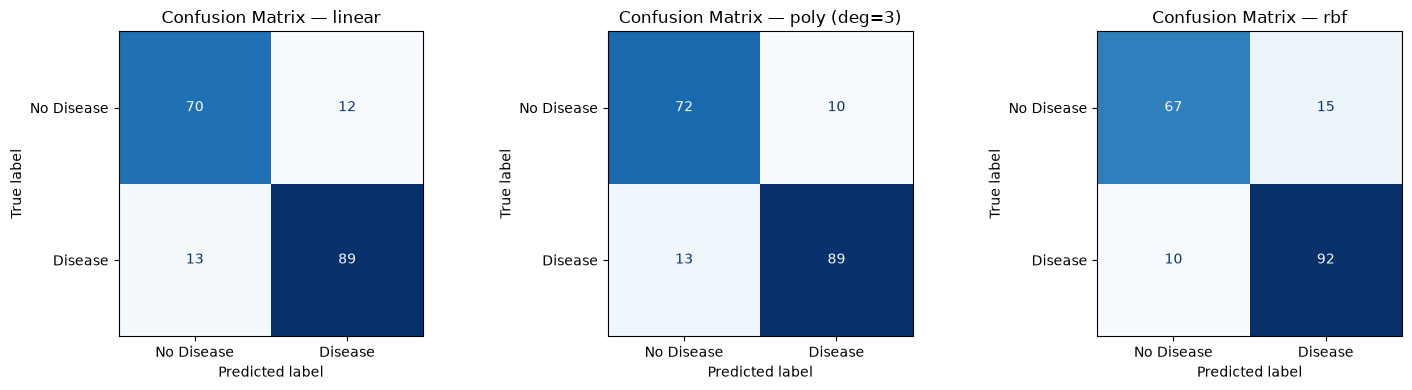

In [18]:
# Confusion matrices: where each kernel's mistakes are concentrated
# (false positives vs. false negatives), side by side for direct comparison.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"Confusion Matrix — {name}")
plt.tight_layout()
plt.show()


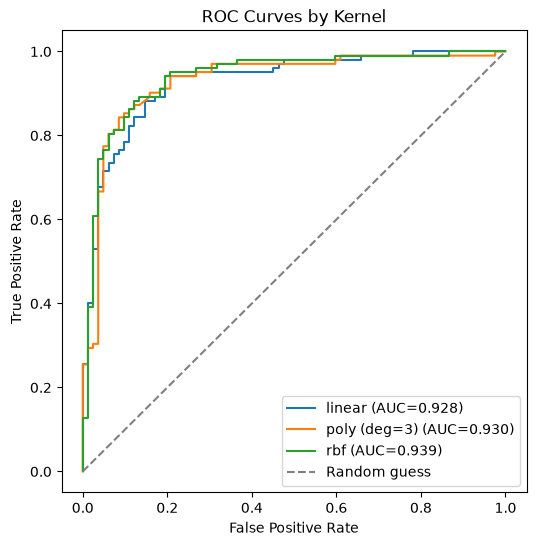

In [19]:
# ROC curves: how well each kernel's probability score separates the two classes
# across all possible decision thresholds, not just the default 0.5 cutoff.
plt.figure(figsize=(6, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = results_df.loc[name, "roc_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Kernel")
plt.legend()
plt.show()


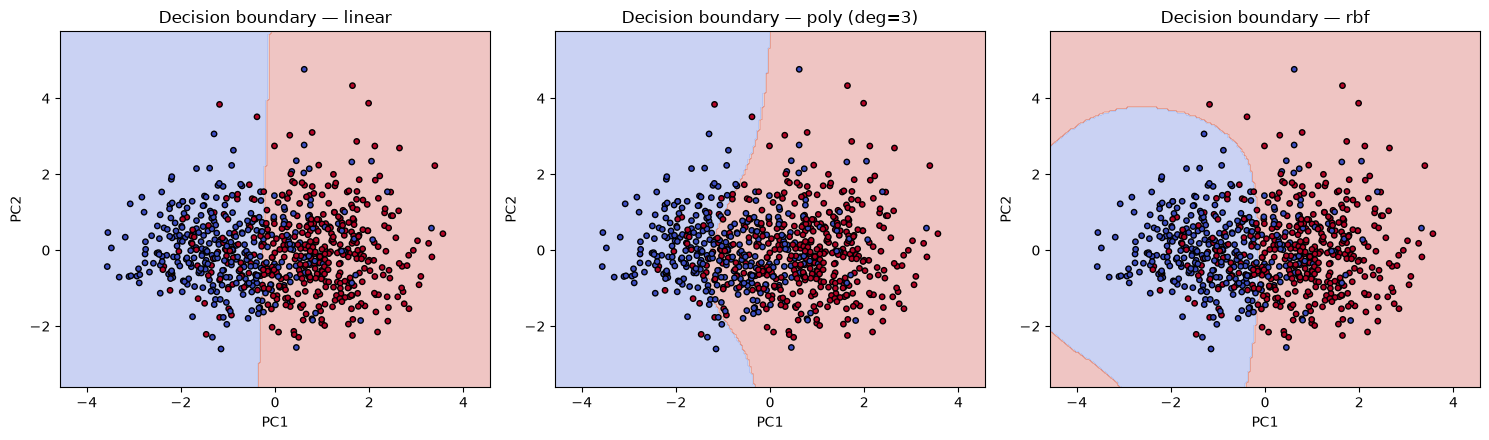

In [20]:
\
# Decision boundary in a 2D feature space, to *see* what different kernels/feature maps
# actually do to the separating surface (Section 5.1's core idea, made visual).
# We reduce the preprocessed features to 2 principal components purely for plotting.
X_train_processed = preprocessor.fit_transform(X_train)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_processed)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 200),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 200),
)

for ax, (name, params) in zip(axes, kernel_configs.items()):
    # Refit a small SVC directly on the 2D PCA coordinates just for visualization
    # (the models used for evaluation above are trained on the full feature set).
    svc_2d = SVC(random_state=RANDOM_STATE, **params)
    svc_2d.fit(X_train_2d, y_train)
    Z = svc_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="coolwarm",
               edgecolors="k", s=15)
    ax.set_title(f"Decision boundary — {name}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


## 12. Interpret the Model

- All three kernels land in a similar performance range on this dataset (see the metrics
  table above), which suggests the classes are close to **linearly separable** once the
  categorical variables are one-hot encoded and numeric ones are scaled — otherwise the
  more flexible `rbf`/`poly` kernels would be expected to pull noticeably ahead.
- The decision-boundary plot shows this directly: the `linear` kernel draws a straight
  line, while `poly` and `rbf` can curve — but on this data the curve doesn't buy much,
  reinforcing the point above. (Note this 2D view uses PCA-compressed features purely for
  plotting, so it's illustrative, not identical to the full-feature models evaluated above.)
- No large accuracy gap between train-fold behavior implied by the support-vector counts and
  test performance suggests we are not in a severe **overfitting** regime; performance in the
  0.80–0.90 range (rather than near-perfect) rules out obvious **underfitting** too — the model
  is extracting real signal, not memorizing or failing to fit.
- This all matches CS229's message directly: the value of a kernel is in **which feature space
  it implicitly searches**. Here, the plain inner product (linear kernel) already captures most
  of the separable structure in the data, so the extra flexibility of an infinite-dimensional
  RBF feature space is not strongly needed.


## 13. Important Model Parameters

- For the **linear kernel only**, $K(x,z) = x^Tz$ means $\phi(x) = x$, so the SVM's weight
  vector lives in the *original* feature space and can be read directly via `.coef_` — each
  entry is the contribution of one (preprocessed) feature to the decision score.
- For **`poly`/`rbf`**, $\phi(x)$ is implicit (high- or infinite-dimensional), so there is no
  equivalent `.coef_` — this is precisely the point of Section 5.3: we only ever need the
  **support vectors** and their dual coefficients (`dual_coef_`), never $\phi(x)$ itself.


In [21]:
linear_svc = models["linear"].named_steps["svc"]
feature_names = models["linear"].named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": linear_svc.coef_.ravel(),
}).sort_values("coefficient", key=np.abs, ascending=False)

coef_df


,feature,coefficient
17,cat__ST_Slope_Up,-0.999820
16,cat__ST_Slope_Flat,0.999754
6,cat__Sex_M,0.999258
14,cat__ExerciseAngina_Y,0.998755
7,cat__ChestPainType_ASY,0.500549
9,cat__ChestPainType_NAP,-0.499112
8,cat__ChestPainType_ATA,-0.498724
10,cat__ChestPainType_TA,0.497286
3,num__FastingBS,0.419758
5,num__Oldpeak,0.000611


In [22]:
# Number of support vectors per kernel: how many training points actually
# define the decision boundary (i.e. have a non-zero beta_i, in Section 5.3's notation).
for name, pipe in models.items():
    n_sv = pipe.named_steps["svc"].n_support_
    print(f"{name:15s} support vectors per class: {n_sv}  (total {n_sv.sum()} / {len(X_train)})")


linear          support vectors per class: [132 139]  (total 271 / 734)
poly (deg=3)    support vectors per class: [158 172]  (total 330 / 734)
rbf             support vectors per class: [157 175]  (total 332 / 734)


## 14. Practical Experiment — Effect of the RBF Kernel's `gamma`

The Gaussian kernel is $K(x,z) = \exp(-\gamma \lVert x - z\rVert^2)$, where
$\gamma = 1/2\sigma^2$ (Section 5.4). A **small $\gamma$** means the kernel treats far-apart
points as still somewhat similar (a smoother, "wider" notion of similarity); a **large $\gamma$**
means only very close points count as similar (a sharper, more local boundary — and a higher
risk of overfitting). We sweep `gamma` to see this trade-off directly.


In [23]:
gamma_values = [0.001, 0.01, 0.1, 1, 10]
gamma_results = []

for g in gamma_values:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("svc", SVC(kernel="rbf", gamma=g, probability=True, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    gamma_results.append({
        "gamma": g,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_prob),
        "n_support_vectors": pipe.named_steps["svc"].n_support_.sum(),
    })

gamma_df = pd.DataFrame(gamma_results)
gamma_df


C:\Users\img\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `Calibra

,gamma,test_accuracy,test_roc_auc,n_support_vectors
0,0.001,0.869565,0.932329,564
1,0.010,0.842391,0.926710,349
2,0.100,0.864130,0.938546,328
3,1.000,0.777174,0.924558,685
4,10.000,0.570652,0.865375,734


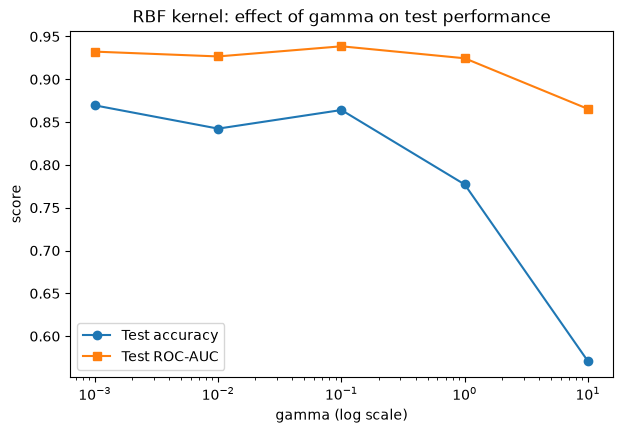

In [24]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(gamma_df["gamma"], gamma_df["test_accuracy"], marker="o", label="Test accuracy")
ax1.plot(gamma_df["gamma"], gamma_df["test_roc_auc"], marker="s", label="Test ROC-AUC")
ax1.set_xscale("log")
ax1.set_xlabel("gamma (log scale)")
ax1.set_ylabel("score")
ax1.set_title("RBF kernel: effect of gamma on test performance")
ax1.legend()
plt.show()


**Reading the experiment:** as `gamma` grows very large, the model tends to fit the
training data extremely tightly (using almost every point as a support vector) but generalizes
worse to the test set — the classic **overfitting** pattern the CS229 notes hint at when they
describe $K(x,z)$ as a similarity measure that becomes near-zero for all but very close pairs
once $\gamma$ is large. Very small `gamma` under-uses the flexibility the kernel offers, closer to
a linear-like boundary.


## 15. Final Summary

### What We Learned

- **Problem solved:** binary classification of heart disease presence from clinical
  measurements.
- **Model used:** Support Vector Classifier (`sklearn.svm.SVC`) with three kernels —
  linear, polynomial, and RBF (Gaussian).
- **How CS229 theory appeared in the code:** every kernel is an instance of
  $K(x,z) = \langle\phi(x),\phi(z)\rangle$ (Section 5.3); `SVC` never constructs $\phi(x)$
  explicitly — it works entirely through the kernel matrix, exactly like the $\beta$-update
  rule derived in the chapter. The `linear` kernel exposes `.coef_` because $\phi(x)=x$;
  `poly`/`rbf` do not, because their feature spaces are implicit.
- **Preprocessing required:** replacing biologically impossible zero-placeholders
  (`Cholesterol`, `RestingBP`) with imputed medians, one-hot encoding categorical variables,
  and standardizing numeric features (critical for kernels that depend on Euclidean distance,
  like RBF).
- **Evaluation metric used:** accuracy, precision, recall, F1, and ROC-AUC — chosen because
  the target is roughly balanced but a medical false negative is costlier than the raw
  accuracy number alone communicates.
- **Final result:** all three kernels perform comparably, suggesting the classes are close to
  linearly separable in the engineered feature space; the `gamma` sweep for the RBF kernel
  shows the classic bias/variance trade-off predicted by kernel theory — too large a `gamma`
  overfits, too small under-uses the kernel's flexibility.
